In [1]:
"""Compare from-scratch linear classifiers on handwritten digits 3 and 9."""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn import model_selection, svm
from sklearn.datasets import load_digits
from sklearn.model_selection import ShuffleSplit, StratifiedKFold, StratifiedShuffleSplit


## Objective

This notebook implements and evaluates several linear classifiers for distinguishing handwritten **3s** from **9s**. It compares a PCA-based nearest-mean baseline, a custom LDA implementation, a custom linear SVM trained with batch gradient descent, and a scikit-learn reference model.

In [2]:
digits = load_digits ()
print ( digits . keys () )
data = digits ['data']
images = digits ['images']
target = digits ['target']
target_names = digits ['target_names']

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


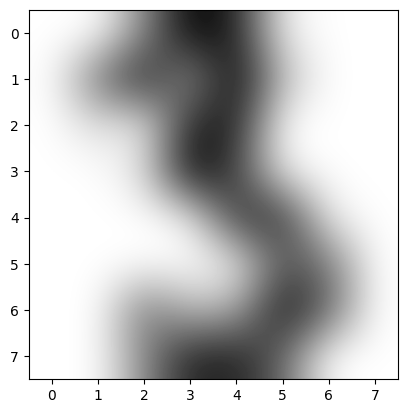

In [3]:
plt.imshow(images[target == 3][0], interpolation='bicubic', cmap='gray_r')

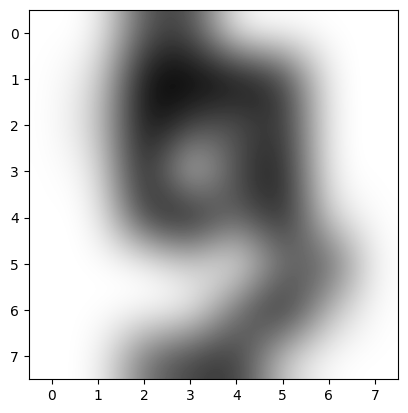

In [4]:

plt.imshow(images[target == 9][0], interpolation='bicubic', cmap='gray_r')

## Data preparation

Select digits 3 and 9, flatten each 8×8 image into 64 features, and create a reproducible hold-out split for exploratory visualisations. Cross-validation is introduced later for model comparison.

In [5]:
# Restrict the multiclass digits dataset to the binary 3-versus-9 task.
digits = load_digits()
data = digits["data"]
images = digits["images"]
target = digits["target"]

binary_mask = np.isin(target, [3, 9])
X_all = data[binary_mask]
y_all = target[binary_mask]

# Keep this fixed split for introductory visualisations and quick checks.
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_all,
    y_all,
    test_size=0.4,
    random_state=2,
    shuffle=True,
)


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


## Baseline: nearest class mean in PCA space

The baseline projects samples onto principal components and assigns a label according to the nearest class centroid. It provides an interpretable reference before fitting discriminative models.

In [12]:
class HandcraftedClassifier:
    """Nearest-class-mean baseline with PCA and pixel-selection features."""
    def __init__(self, X_train, y_train, X_test, y_test):
        self.training_features = X_train
        self.training_labels = y_train
        self.test_features = X_test
        self.test_labels = y_test

        self.training_mean = np.mean(X_train, axis=0)
        # Fit the centring transform on training data and reuse it for test data.
        self.training_features_centered = X_train - self.training_mean

   

    def fitPCA(self, X, n_components):
        """Fit PCA with singular-value decomposition and store the fitted basis.

        The principal components and covariance eigenvalues are written to
        ``self.principal_components`` and ``self.explained_variance``.
        """

        centered_data = X - np.mean(X, axis=0)
        # Singular-value decomposition yields principal directions in Vt.
        _, singular_values, Vt = np.linalg.svd(centered_data, full_matrices=False)

        # Retain directions with the largest sample variance.
        components = Vt[:n_components]

        # Convert singular values to covariance eigenvalues.
        explained_variance = (singular_values**2) / (X.shape[0] - 1)
        
        self.principal_components = components
        self.explained_variance = explained_variance

    # Project samples from pixel space into a fitted PCA basis.
    def BasischangeGridToPCA(self, X, mean, components):
        X_centered = X - mean
        return X_centered @ components.T

    # Reconstruct samples from PCA coordinates into pixel space.
    def BasischangePCAToGrid(self, X, mean, components):
        return X @ components + mean


    def features2d_Naive_Max(self, test_data, n_components):
        ''' 
        The Naive_Max identifies the pixels with the largest absolute difference in mean pixel intensity between the two classes (3 and 9) and projects the data onto those pixels.
        If override_pixels is provided, it will use those pixels instead of the ones with the largest differences. The function returns the indices of the selected pixels and the projected data for both classes.
        '''
        data3 = self.training_features[self.training_labels == 3]
        data9 = self.training_features[self.training_labels == 9]
        data3_mean = data3.mean(axis=0)
        data9_mean = data9.mean(axis=0)

        N3 = len(data3)
        N9 = len(data9)
        mean = (N3 * data3_mean + N9 * data9_mean) / (N3 + N9) # Compute the overall mean of the data
        data3_centered = data3 - mean
        data9_centered = data9 - mean

        data3_centered_mean = np.mean(data3_centered, axis=0)
        data9_centered_mean = np.mean(data9_centered, axis=0)

        difference = np.abs(data3_centered_mean - data9_centered_mean)

        largest_differences = np.argsort(difference)[-n_components:]

        training_features = self.training_features_centered[:, largest_differences]

        test_centered = test_data - mean

        test_features = test_centered[:, largest_differences]


        return training_features, test_features  
        
    def features2d_PCA(self, n_components):
        '''
        The features2d_PCA function projects the training and test data onto the first n principal components obtained from PCA. It first fits PCA on the centered training data to obtain the principal components, and then projects both the training and test data onto these components to reduce their dimensionality.
        '''
        self.fitPCA(self.training_features, n_components)

        training_features = self.training_features_centered @ self.principal_components.T

        test_centered = self.test_features - self.training_mean
        test_features = test_centered @ self.principal_components.T

        # Compute cluster means in PCA space
        self.PCA_Cluster3_mean = np.mean(training_features[self.training_labels == 3], axis=0)
        self.PCA_Cluster9_mean = np.mean(training_features[self.training_labels == 9], axis=0)

        return training_features, test_features

    
    
    def Distance_Classifier(self, point, mu1, mu2):
        '''
        Classify a point based on its distance to the mean of the two clusters (3 and 9) in the PCA feature space. The function computes the Euclidean distance from the point to each cluster mean and assigns the class label corresponding to the nearest mean.
        '''
        if np.linalg.norm(point - mu1) < np.linalg.norm(point - mu2):
            return 3
        else:
            return 9
    

    def nearest_mean(self, training_features, test_features):
        '''
        Classify the training and test data using the Distance_Classifier. The function iterates over each point in the training and test feature sets, applies the Distance_Classifier to determine the predicted class label, and returns the predictions for both sets.
        '''
        training_predictions = []
        test_predictions = []
        for features in training_features:
            training_predictions.append(self.Distance_Classifier(features, self.PCA_Cluster3_mean, self.PCA_Cluster9_mean))
        for features in test_features:
            test_predictions.append(self.Distance_Classifier(features, self.PCA_Cluster3_mean, self.PCA_Cluster9_mean))

        return training_predictions, test_predictions


    def visualise_clusters(self, resolution= 200, title_text = None):
        '''
        Visualize the decision boundary of the classifier in the PCA feature space. The function creates a grid of points covering the range of the features, classifies each point using the Distance_Classifier, and then plots the training and test data along with the decision boundary.
        '''

        
        plot_features = self.training_features
        plot_labels = self.training_labels
        plot_mean = np.mean(plot_features, axis=0)
        centered_features = plot_features - np.mean(plot_features, axis=0)

        mu1 = np.mean(plot_features[plot_labels == 3], axis=0)
        mu2 = np.mean(plot_features[plot_labels == 9], axis=0)

        self.fitPCA(centered_features, n_components=2)

        # After projecting the data onto the first 2 principal components
        Features_2D = centered_features @ self.principal_components.T
        mu1 = mu1 @ self.principal_components.T
        mu2 = mu2 @ self.principal_components.T

        x_min = Features_2D[:, 0].min() - 1
        x_max = Features_2D[:, 0].max() + 1
        y_min = Features_2D[:, 1].min() - 1
        y_max = Features_2D[:, 1].max() + 1

        x = np.linspace(x_min, x_max, resolution)
        y = np.linspace(y_min, y_max, resolution)
        xx, yy = np.meshgrid(x, y, indexing='xy')

        Z = np.zeros(xx.shape, dtype=int)

        for i in range(xx.shape[0]):
            for j in range(xx.shape[1]):
                point = np.array([xx[i, j], yy[i, j]])
                

                Z[i, j] = self.Distance_Classifier(point, mu1, mu2)
        
        
    
        plt.figure(figsize=(8, 6))     
        plt.contourf(xx, yy, Z, colors=['lightblue', 'lightcoral'], alpha=0.4, levels=[2, 5, 10], extend='both')

        if title_text is not None:
            plt.title('Decision Boundary and Data Points ' + title_text)
        else:
            plt.title('Decision Boundary and Data Points')

        for label in np.unique(plot_labels):
            mask = plot_labels == label
            marker = 'o' if label == 3 else 's'
            color = 'aqua' if label == 3 else 'coral'
            plt.scatter(
                Features_2D[mask, 0],
                Features_2D[mask, 1],
                color=color,
                edgecolor='k',
                marker=marker,
                label=f'Class {label}'
            )
        
        plt.scatter(mu1[0], mu1[1], c='blue', label='Mean 3', marker=">", s=300)
        plt.scatter(mu2[0], mu2[1], c='red', label='Mean 9', marker='<', s=300)
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')

        
        
        plt.legend(fontsize='small', handlelength=2.5, handletextpad=1.0, borderpad=0.8)
        plt.show()



Training error: = 1.8399999999999999 %
Test error: = 1.37 %


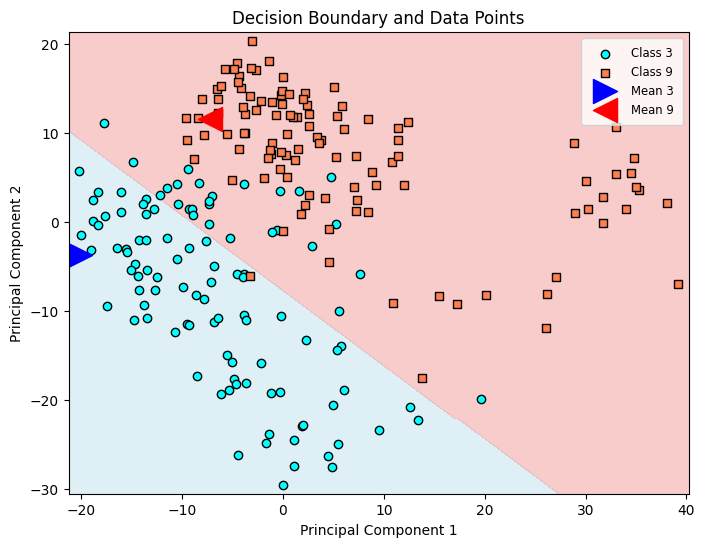

In [13]:
Training_instance = HandcraftedClassifier(X_train, y_train, X_test, y_test)

training_features_PCA, test_features_PCA = Training_instance.features2d_PCA(n_components=10)

training_predictions, test_predictions = Training_instance.nearest_mean(training_features_PCA, test_features_PCA)
print("Training error: =", np.round(np.mean(np.array(training_predictions) != y_train), 4)*100, "%")
print("Test error: =", 100*np.round(np.mean(np.array(test_predictions) != y_test), 4), "%")

Training_instance.visualise_clusters(resolution=200)
del(Training_instance)


## Linear Discriminant Analysis

LDA models both classes with Gaussian distributions that share a covariance matrix. Under this assumption, the log-likelihood ratio is linear in the input features.

In [ ]:
class LDA:
    """Binary LDA classifier with an optional constant-feature filter."""
    def __init__(self, X_train_input, y_train_input, X_test_input= None, y_test_input= None, FilterDeadPixels=False):
        self.training_features = X_train_input
        self.training_labels = y_train_input     

        self.test_features = X_test_input
        self.test_labels = y_test_input

        if (FilterDeadPixels):
            PixelsToDelete = self.filter_dead_pixels(self.training_features)
            self.training_features = np.delete(self.training_features, PixelsToDelete, axis=1) 
            self.test_features = np.delete(self.test_features, PixelsToDelete, axis=1)

    
    def filter_dead_pixels(self, X, threshold = 0.001):
        # Remove features with negligible variance to avoid singular covariance directions.
        var = np.var(X, axis=0)
        dead_pixels = np.where(var < threshold)[0]

        return dead_pixels
    
    
    def fit_LDA(self, training_features = None, training_labels = None):

        if training_features is not None:
            self.training_features = training_features
        if training_labels is not None:
            self.training_labels = training_labels

        labels = np.unique(self.training_labels)
        label_1, label_2 = labels[:2]

        mu_1 = np.mean(self.training_features[self.training_labels == label_1], axis=0)
        mu_2 = np.mean(self.training_features[self.training_labels == label_2], axis=0)

        x_1 = self.training_features[self.training_labels == label_1]

        x_2 = self.training_features[self.training_labels == label_2]

        N = self.training_features.shape[0]

        # Estimate a pooled within-class covariance matrix.
        self.sigma = 1 / N * ((x_1 - mu_1).T @ (x_1 - mu_1) + (x_2 - mu_2).T @ (x_2 - mu_2))

        self.mu = np.array([mu_1, mu_2])

        self.prior = np.array([len(x_1) / N, len(x_2) / N])

        return self.mu, self.sigma, self.prior

    
    def predict_LDA(self, mu_input= None, covmat_input= None, p_input= None):

        if mu_input is not None:
            self.mu = mu_input
        if covmat_input is not None:
            self.sigma = covmat_input
        if p_input is not None:
            self.prior = p_input     

        self.beta = np.linalg.inv(self.sigma) @ (self.mu[1] - self.mu[0])

        # Include the log prior odds in the affine discriminant intercept.

        self.b = -1/2 * (self.mu[1] + self.mu[0])@self.beta + np.log(self.prior[1]/self.prior[0])

        test_scores = self.test_features @ self.beta + self.b

        training_scores = self.training_features @ self.beta + self.b

        self.predicted_test_labels = np.where(test_scores > 0, 9, 3)
        self.predicted_training_labels = np.where(training_scores > 0, 9, 3)

        return
    
    def predict_LDA_single(self, Point):
        score = Point @ self.beta + self.b
        return np.where(score > 0, 9, 3)




    def evaluate(self):

        training_error = np.mean(self.predicted_training_labels != self.training_labels)
        test_error = np.mean(self.predicted_test_labels != self.test_labels)
        print("Training error: =", np.round(training_error, 4)*100, "%")
        print("Test error: =", np.round(test_error, 4)*100, "%")

        return training_error, test_error


    def fitPCA(self, X, n_components):
        """Fit PCA with singular-value decomposition and store the fitted basis.

        The principal components and covariance eigenvalues are written to
        ``self.principal_components`` and ``self.explained_variance``.
        """

        centered_data = X - np.mean(X, axis=0)
        # Singular-value decomposition yields principal directions in Vt.
        _, singular_values, Vt = np.linalg.svd(centered_data, full_matrices=False)

        # Retain directions with the largest sample variance.
        components = Vt[:n_components]

        # Convert singular values to covariance eigenvalues.
        explained_variance = (singular_values**2) / (X.shape[0] - 1)
        
        self.principal_components = components
        self.explained_variance = explained_variance

    # Project samples from pixel space into a fitted PCA basis.
    def BasischangeGridToPCA(self, X, mean, components):
        X_centered = X - mean
        return X_centered @ components.T

    # Reconstruct samples from PCA coordinates into pixel space.
    def BasischangePCAToGrid(self, X, mean, components):
        return X @ components + mean


    def visualise_clusters(self, resolution= 200, title_text = None):
        """Visualise the fitted LDA boundary in a two-dimensional PCA projection.

        Projection-grid points are reconstructed into pixel space before LDA
        predictions are computed, so the figure represents the full-space model.
        """

        
        plot_features = self.training_features
        plot_labels = self.training_labels
        plot_mean = np.mean(plot_features, axis=0)
        centered_features = plot_features - np.mean(plot_features, axis=0)

        mu1 = self.mu[0]
        mu2 = self.mu[1]

        self.fitPCA(centered_features, n_components=2)

        # After projecting the data onto the first 2 principal components
        Features_2D = centered_features @ self.principal_components.T
        mu1 = mu1 @ self.principal_components.T
        mu2 = mu2 @ self.principal_components.T

        x_min = Features_2D[:, 0].min() - 1
        x_max = Features_2D[:, 0].max() + 1
        y_min = Features_2D[:, 1].min() - 1
        y_max = Features_2D[:, 1].max() + 1

        x = np.linspace(x_min, x_max, resolution)
        y = np.linspace(y_min, y_max, resolution)
        xx, yy = np.meshgrid(x, y, indexing='xy')

        Z = np.zeros(xx.shape, dtype=int)

        for i in range(xx.shape[0]):
            for j in range(xx.shape[1]):
                point = np.array([xx[i, j], yy[i, j]])
                
                # Map projection-grid coordinates back to pixel space before prediction.

                Original_point = point@self.principal_components + plot_mean
                Z[i, j] = self.predict_LDA_single(Point=Original_point)
        
        
    
        plt.figure(figsize=(8, 6))     
        plt.contourf(xx, yy, Z, colors=['lightblue', 'lightcoral'], alpha=0.4, levels=[2, 5, 10], extend='both')

        if title_text is not None:
            plt.title('Decision Boundary and Data Points ' + title_text)
        else:
            plt.title('Decision Boundary and Data Points')

        for label in np.unique(plot_labels):
            mask = plot_labels == label
            marker = 'o' if label == 3 else 's'
            color = 'aqua' if label == 3 else 'coral'
            plt.scatter(
                Features_2D[mask, 0],
                Features_2D[mask, 1],
                color=color,
                edgecolor='k',
                marker=marker,
                label=f'Class {label}'
            )
        
        plt.scatter(mu1[0], mu1[1], c='blue', label='Mean 3', marker=">", s=300)
        plt.scatter(mu2[0], mu2[1], c='red', label='Mean 9', marker='<', s=300)
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')

      

        plt.legend(fontsize='small', handlelength=2.5, handletextpad=1.0, borderpad=0.8)
        plt.show()




### LDA after PCA projection

This experiment fits LDA on the first ten principal components, testing whether a low-dimensional representation retains enough class-discriminating information.

Training error: = 0.45999999999999996 %
Test error: = 0.0 %


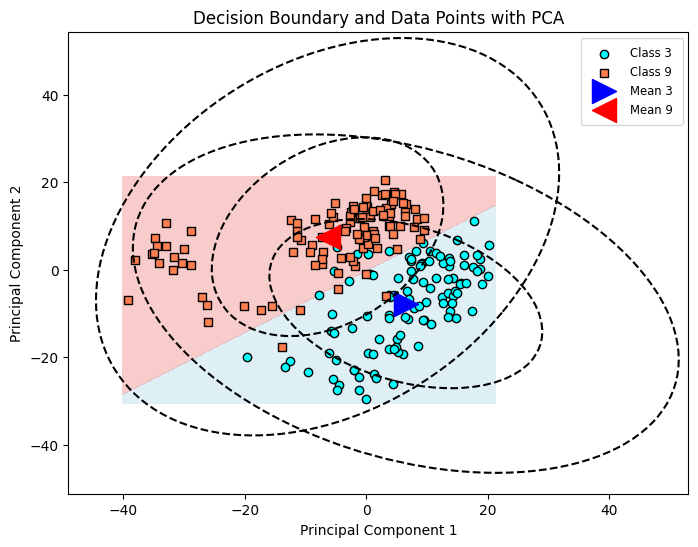

In [19]:


LDA_with_PCA = LDA(X_train_input=training_features_PCA, y_train_input= y_train, X_test_input= test_features_PCA, y_test_input=y_test)
LDA_with_PCA.fit_LDA()
LDA_with_PCA.predict_LDA()
LDA_with_PCA.evaluate()
LDA_with_PCA.visualise_clusters(resolution=300, title_text = "with PCA")

del(LDA_with_PCA)

### LDA using the full feature representation

This experiment fits LDA directly on non-constant pixel features. The PCA plot is used only to visualise the full-space decision boundary.

Training error: = 0.0 %
Test error: = 2.0500000000000003 %


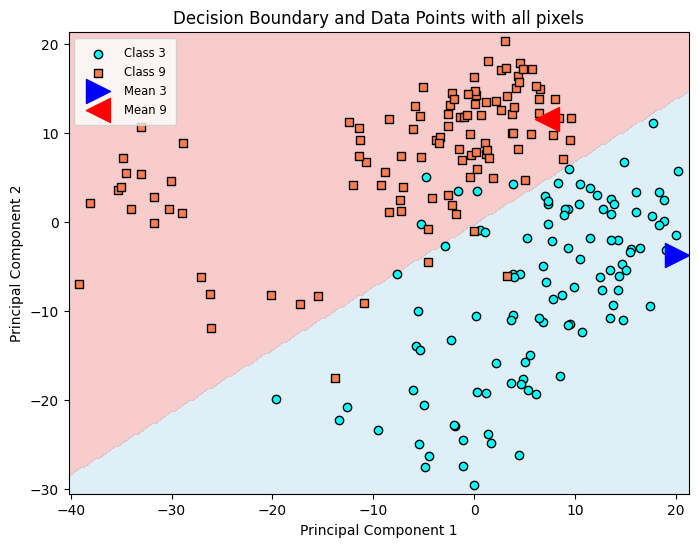

In [184]:
LDA_all_pixels = LDA(X_train_input=X_train, y_train_input=y_train, X_test_input=X_test, y_test_input=y_test, FilterDeadPixels=True)
LDA_all_pixels.fit_LDA()
LDA_all_pixels.predict_LDA()
LDA_all_pixels.evaluate()
LDA_all_pixels.visualise_clusters(resolution=200, title_text= "with all pixels")
del(LDA_all_pixels)

In [185]:

def Shuffled_CV(X, y, n_splits=5, test_size=0.4, random_state=0):
    """Return repeated random train/test index splits without stratification."""

    cv = ShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

    DataSplit = []
    for train_index, test_index in cv.split(X):

        DataSplit.append((train_index, test_index))
    return DataSplit


def StratifiedKFold_CV(X, y, n_splits=5, random_state=5):
    """Return shuffled stratified K-fold index splits."""
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    DataSplit = []
    for train_index, test_index in cv.split(X, y):
        DataSplit.append((train_index, test_index))
        

    return DataSplit

def StratifiedShuffleSplit_CV(X, y, n_splits=5, test_size=0.4, random_state=5):
    """Return repeated shuffled splits that preserve class proportions."""
    
    cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

    DataSplit = []
    for train_index, test_index in cv.split(X, y):
        DataSplit.append((train_index, test_index))
        

    return DataSplit


def RunCV_LDA(X, y, DataSplit, method_name="", PlotDataSplits=False):
    """Evaluate the custom LDA model across precomputed validation splits."""
    training_errors = []
    test_errors = []
    for train_index, test_index in DataSplit:
        LDA_instance = LDA(X_train_input=X[train_index], y_train_input=y[train_index], X_test_input=X[test_index], y_test_input=y[test_index], FilterDeadPixels=True)
        LDA_instance.fit_LDA()
        LDA_instance.predict_LDA()
        training_error, test_error = LDA_instance.evaluate()
        training_errors.append(training_error)
        test_errors.append(test_error)
        del(LDA_instance)
    
    average_training_error = np.mean(training_errors)
    average_test_error = np.mean(test_errors)
    print("Average training error across splits: ", np.round(average_training_error, 4)*100, "%")
    print("Average test error across splits: ", np.round(average_test_error, 4)*100, "%")

    if PlotDataSplits:
        fig, axes = plt.subplots(
            len(DataSplit),
            1,
            figsize=(12, 5),
            sharex=True,
            constrained_layout=True
        )

        # Normalise the single-split case to an iterable of axes.
        if len(DataSplit) == 1:
            axes = [axes]

        
        fig.suptitle("K-Fold Cross Validation Splits "+ method_name, fontsize=16)
        
        fig.supxlabel("Sample Index")
        fig.supylabel("Split Index")

        n_samples = len(y_all)

        for split_idx, (train_idx, test_idx) in enumerate(DataSplit):

            ax = axes[split_idx]

            # Draw the complete sample-index range as context.
            ax.barh(
                y=0,
                width=n_samples,
                left=0,
                height=0.6,
                color="lightgray",
                edgecolor="none"
            )

            # Overlay training-sample indices.
            ax.barh(
                y=np.zeros_like(train_idx),
                width=1,
                left=train_idx,
                height=0.6,
                color="skyblue",
                edgecolor="none"
            )

            # Overlay held-out sample indices.
            ax.barh(
                y=np.zeros_like(test_idx),
                width=1,
                left=test_idx,
                height=0.6,
                color="salmon",
                edgecolor="none"
            )

            ax.set_yticks([])
            ax.set_ylabel(f"{split_idx+1}", rotation=0, labelpad=15)

            # Configure shared x-axis ticks on the final subplot.
            axes[-1].set_xticks(np.arange(0, n_samples + 1, 20))

            # Remove visual clutter from the split diagram.
            for ax in axes:
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['left'].set_visible(False)

            # Define a shared legend for the split diagram.
            legend_elements = [
                Patch(facecolor='skyblue', label='Training Set'),
                Patch(facecolor='salmon', label='Test Set'),
            ]

        fig.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True
        )

        plt.show()

    return [average_training_error, average_test_error]

In [186]:
DataSplit_Shuffled = Shuffled_CV(X_all, y_all, n_splits=10, test_size=0.4, random_state=204)
DataSplit_StratifiedKFold = StratifiedKFold_CV(X_all, y_all, n_splits=10, random_state=5)
DataSplit_StratifiedShuffleSplit = StratifiedShuffleSplit_CV(X_all, y_all, n_splits=10, test_size=0.4, random_state=5)



Training error: = 0.45999999999999996 %
Test error: = 2.0500000000000003 %
Training error: = 0.45999999999999996 %
Test error: = 0.6799999999999999 %
Training error: = 0.0 %
Test error: = 2.74 %
Training error: = 0.0 %
Test error: = 2.0500000000000003 %
Training error: = 0.45999999999999996 %
Test error: = 2.74 %
Training error: = 0.45999999999999996 %
Test error: = 2.0500000000000003 %
Training error: = 50.690000000000005 %
Test error: = 50.68 %
Training error: = 0.45999999999999996 %
Test error: = 1.37 %
Training error: = 0.0 %
Test error: = 2.0500000000000003 %
Training error: = 0.45999999999999996 %
Test error: = 2.0500000000000003 %
Average training error across splits:  5.35 %
Average test error across splits:  6.8500000000000005 %


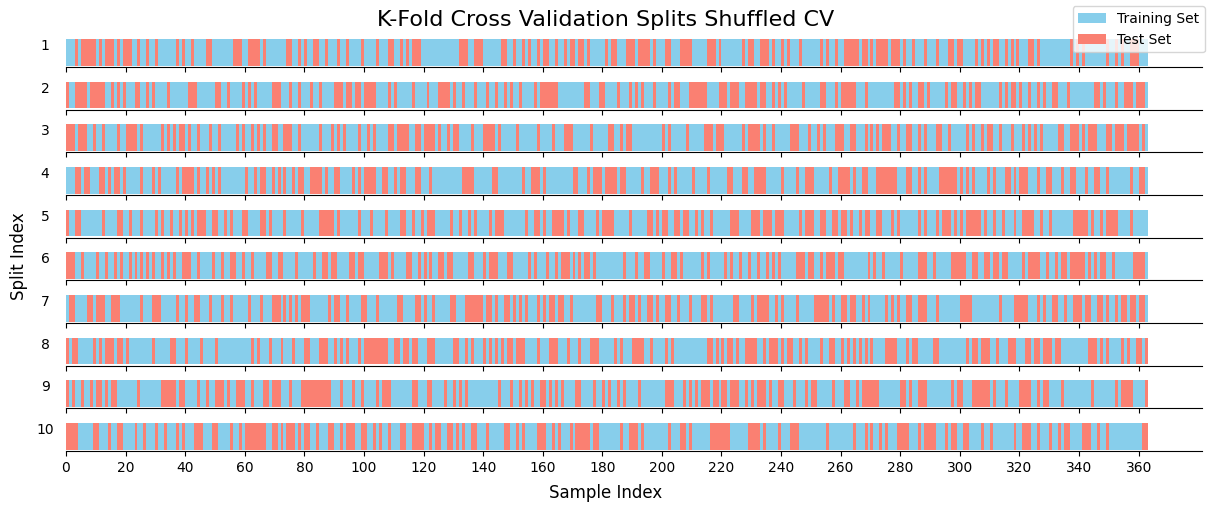

In [187]:
LDA_ShuffledErrors = RunCV_LDA(X_all, y_all, DataSplit_Shuffled, method_name = "Shuffled CV", PlotDataSplits=True)

Training error: = 46.01 %
Test error: = 48.65 %
Training error: = 0.31 %
Test error: = 0.0 %
Training error: = 0.31 %
Test error: = 2.7 %
Training error: = 0.31 %
Test error: = 0.0 %
Training error: = 0.31 %
Test error: = 0.0 %
Training error: = 0.31 %
Test error: = 2.78 %
Training error: = 0.31 %
Test error: = 5.56 %
Training error: = 0.31 %
Test error: = 2.78 %
Training error: = 0.31 %
Test error: = 0.0 %
Training error: = 0.61 %
Test error: = 0.0 %
Average training error across splits:  4.91 %
Average test error across splits:  6.25 %


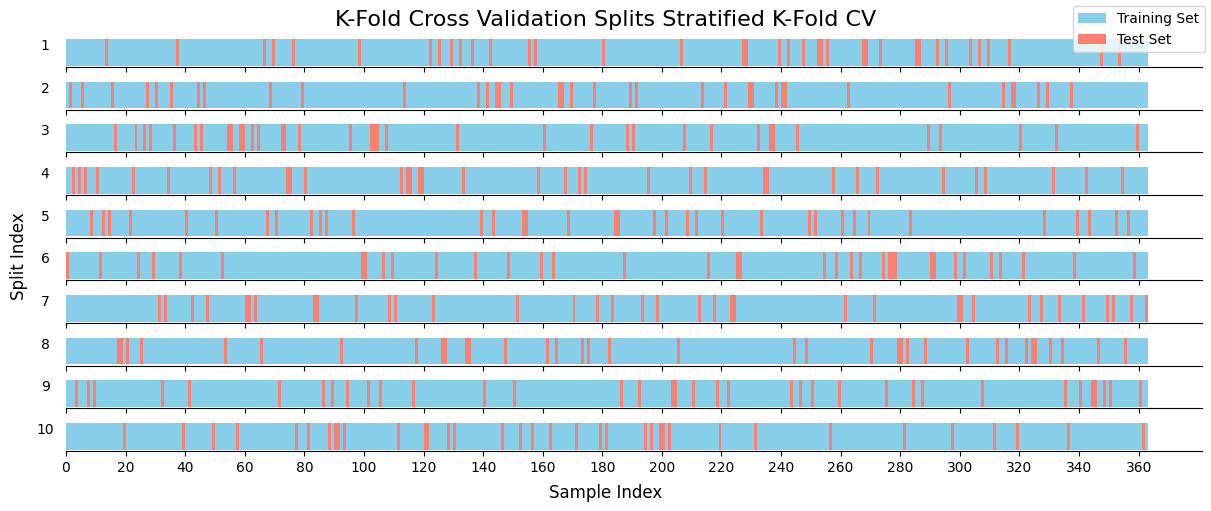

In [188]:
LDA_StratifiedKFoldErrors = RunCV_LDA(X_all, y_all, DataSplit_StratifiedKFold, method_name = "Stratified K-Fold CV", PlotDataSplits=True)

Training error: = 0.45999999999999996 %
Test error: = 0.6799999999999999 %
Training error: = 0.0 %
Test error: = 3.42 %
Training error: = 0.45999999999999996 %
Test error: = 0.0 %
Training error: = 0.45999999999999996 %
Test error: = 1.37 %
Training error: = 0.45999999999999996 %
Test error: = 4.79 %
Training error: = 0.45999999999999996 %
Test error: = 0.6799999999999999 %
Training error: = 0.45999999999999996 %
Test error: = 0.6799999999999999 %
Training error: = 0.45999999999999996 %
Test error: = 1.37 %
Training error: = 0.0 %
Test error: = 2.0500000000000003 %
Training error: = 0.0 %
Test error: = 0.6799999999999999 %
Average training error across splits:  0.32 %
Average test error across splits:  1.58 %


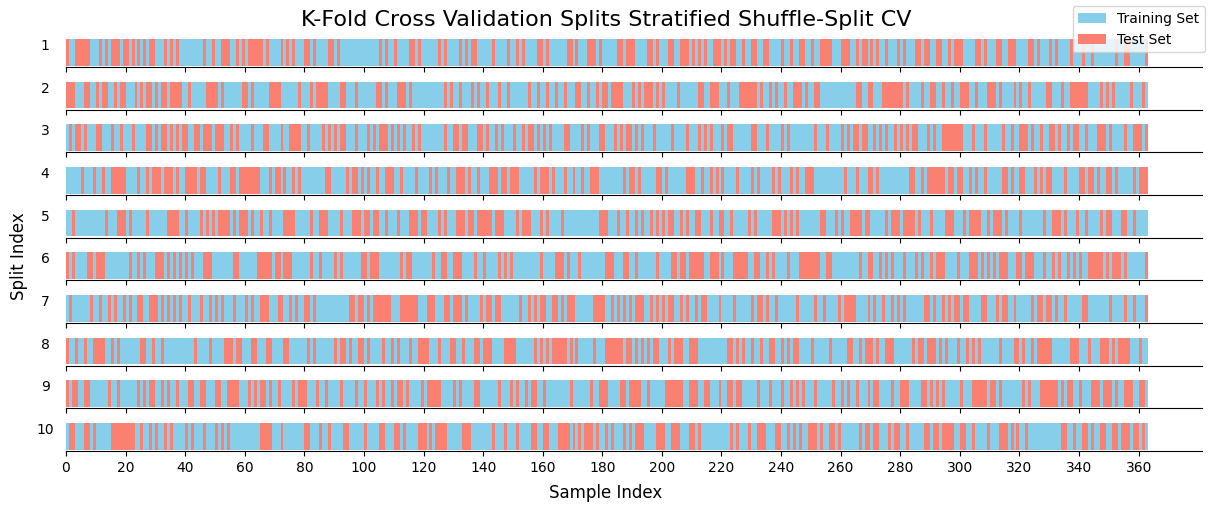

In [189]:
LDA_StratifiedShuffleSplitErrors = RunCV_LDA(X_all, y_all, DataSplit_StratifiedShuffleSplit, method_name = "Stratified Shuffle-Split CV", PlotDataSplits=True)

## Linear Support Vector Machine

The custom SVM optimises an L2-regularised hinge-loss objective with batch gradient descent. Labels are internally mapped from {3, 9} to {-1, +1}; predictions are mapped back for evaluation.

In [6]:
class SVM:
    """Linear binary SVM trained with batch gradient descent on hinge loss."""
    def __init__(self, X_train_input, y_train_input, X_test_input= None, y_test_input= None, FilterDeadPixels=False, WriteOutputEvery=1):
        self.training_features = X_train_input
        self.training_labels = y_train_input     

        self.test_features = X_test_input
        self.test_labels = y_test_input
        self.length_training = self.training_features.shape[0]
        self.WriteOutputEvery = WriteOutputEvery

        self.lambda_reg = 1e-3
        self.learning_rate = 0.2
        self.beta = None
        self.b = None
        self.loss_history = []
        self.training_error_history = []
        if (FilterDeadPixels):
            PixelsToDelete = self.filter_dead_pixels(self.training_features)
            self.training_features = np.delete(self.training_features, PixelsToDelete, axis=1) 
            self.test_features = np.delete(self.test_features, PixelsToDelete, axis=1)

        self.training_mean = np.mean(self.training_features, axis=0)
        self.training_std = np.std(self.training_features, axis=0)

        # Map original digit labels to the signed targets used by the hinge loss.
        self.normed_labels = np.where(self.training_labels == 3, -1, 1)


    def standardise(self, X):
        return(X - self.training_mean) / (self.training_std + 1e-8)
        

    def filter_dead_pixels(self, X, threshold = 0.001):
        var = np.var(X, axis=0)
        dead_pixels = np.where(var < threshold)[0]

        return dead_pixels
    
    def compute_losses(self, X, beta, b):

        N = X.shape[0]

        scores = self.normed_labels * (X @ beta + b)

        # Only margin-violating samples contribute to the hinge-loss gradient.
        mask = scores < 1

        loss = 1/2 * np.linalg.norm(beta)**2 + self.lambda_reg / N * np.sum(1 - scores[mask])

        grad_beta = beta - self.lambda_reg/ N * X[mask].T @ self.normed_labels[mask]

        grad_b = - self.lambda_reg / N * np.sum(self.normed_labels[mask])


        return loss, grad_beta, grad_b


    def fit_SVM(self, learning_rate, lambda_reg, max_iterations, threshold=1e-18, PrintProgress = False):

        self.learning_rate = learning_rate
        self.lambda_reg = lambda_reg


        X = self.standardise(self.training_features)

        N, D = X.shape

        # Initialise the separating hyperplane near zero.
        beta = np.random.normal(0, 0.01, D)
        b = 0.0
        
        beta_array = []
        b_array = []

        for iteration in range(int(max_iterations)):

            loss, grad_beta, grad_b = self.compute_losses(X, beta, b)

            beta = beta - self.learning_rate * grad_beta
            b = b - self.learning_rate * grad_b


            if iteration % self.WriteOutputEvery == 0:
                # Record parameters and diagnostics at the configured interval.
                self.learned_beta = beta
                self.learned_b = b  
                if PrintProgress:
                    print(f"Iteration {iteration}, Loss: {loss:.4f}")
                beta_array.append(beta.copy())
                b_array.append(b)
                self.loss_history.append(loss)
                self.training_error_history.append(np.mean(self.predict_SVM(self.training_features) != self.training_labels))


                if len(self.loss_history) > 5:
                    if abs(self.loss_history[-1] - self.loss_history[-5]) < threshold:
                        print("Convergence reached.")
                        break
  
    
        return beta_array, b_array
    
    
   
    
    def predict_SVM(self, X_input):

        X = self.standardise(X_input)

        scores = X @ self.learned_beta + self.learned_b
        predicted_labels = np.where(scores > 0, 9, 3)
        return predicted_labels
               

    def fitPCA(self, X, n_components):
        """Fit PCA with singular-value decomposition and store the fitted basis.

        The principal components and covariance eigenvalues are written to
        ``self.principal_components`` and ``self.explained_variance``.
        """

        centered_data = X - np.mean(X, axis=0)
        # Singular-value decomposition yields principal directions in Vt.
        _, singular_values, Vt = np.linalg.svd(centered_data, full_matrices=False)

        # Retain directions with the largest sample variance.
        components = Vt[:n_components]

        # Convert singular values to covariance eigenvalues.
        explained_variance = (singular_values**2) / (X.shape[0] - 1)
        
        self.principal_components = components
        self.explained_variance = explained_variance



    def visualise_clusters(self, resolution= 200, title_text = None):
        """Visualise the fitted SVM boundary in a two-dimensional PCA projection.

        Projection-grid points are reconstructed into pixel space before SVM
        predictions are computed, so the figure represents the full-space model.
        """
        labels = np.unique(self.training_labels)
        label_1, label_2 = labels[:2]
       

        
        self.fitPCA(self.training_features, n_components=2)
        plot_mean = np.mean(self.training_features, axis=0)

        Features_2D = (self.training_features - plot_mean) @ self.principal_components.T
        
        plot_labels = self.training_labels
       
        mu1 = Features_2D[self.training_labels == label_1].mean(axis=0)
        mu2 = Features_2D[self.training_labels == label_2].mean(axis=0)
        x_min = Features_2D[:, 0].min() - 1
        x_max = Features_2D[:, 0].max() + 1
        y_min = Features_2D[:, 1].min() - 1
        y_max = Features_2D[:, 1].max() + 1

        x = np.linspace(x_min, x_max, resolution)
        y = np.linspace(y_min, y_max, resolution)
        xx, yy = np.meshgrid(x, y, indexing='xy')

        Z = np.zeros(xx.shape, dtype=int)

        for i in range(xx.shape[0]):
            for j in range(xx.shape[1]):
                point = np.array([xx[i, j], yy[i, j]])
                
                # Map projection-grid coordinates back to pixel space before prediction.

                Original_point = point@self.principal_components + plot_mean
                Z[i, j] = self.predict_SVM(Original_point)
        
        
    
        plt.figure(figsize=(8, 6))     
        plt.contourf(xx, yy, Z, colors=['lightblue', 'lightcoral'], alpha=0.4, levels=[2, 5, 10], extend='both')

        if title_text is not None:
            plt.title('Decision Boundary and Data Points ' + title_text)
        else:
            plt.title('Decision Boundary and Data Points')

        for label in np.unique(plot_labels):
            mask = plot_labels == label
            marker = 'o' if label == 3 else 's'
            color = 'aqua' if label == 3 else 'coral'
            plt.scatter(
                Features_2D[mask, 0],
                Features_2D[mask, 1],
                color=color,
                edgecolor='k',
                marker=marker,
                label=f'Class {label}'
            )
        
        plt.scatter(mu1[0], mu1[1], c='blue', label='Mean 3', marker=">", s=300)
        plt.scatter(mu2[0], mu2[1], c='red', label='Mean 9', marker='<', s=300)
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        
        
        plt.legend(fontsize='small', handlelength=2.5, handletextpad=1.0, borderpad=0.8)
        plt.show()


    def evaluate(self, plot = False):
        
        test_predictions = self.predict_SVM(self.test_features)
        training_predictions = self.predict_SVM(self.training_features)

        training_error = np.mean(training_predictions != self.training_labels)
        test_error = np.mean(test_predictions != self.test_labels)
        print("Training error: =", np.round(training_error, 4)*100, "%")
        print("Test error: =", np.round(test_error, 4)*100, "%")
        
        if plot:
            x_range = np.linspace(0, len(self.loss_history) * self.WriteOutputEvery, len(self.loss_history))

            plt.plot(x_range,self.training_error_history, label="Training Error")
            plt.plot(x_range, self.loss_history, label="Loss")
            ax_loss = plt.gca()
            ax_loss.cla()

            # Left axis: loss
            ax_loss.plot(x_range, self.loss_history, color="tab:red", linewidth=2, label="Loss")
            ax_loss.set_ylabel("Loss", color="tab:red")
            ax_loss.tick_params(axis="y", labelcolor="tab:red")
            loss_min, loss_max = np.min(self.loss_history), np.max(self.loss_history)
            ax_loss.set_yticks(np.linspace(loss_min, loss_max, 6))

            # Right axis: test error history (fallback to constant final test_error if unavailable)
            ax_err = ax_loss.twinx()
            if hasattr(self, "test_error_history") and len(self.test_error_history) == len(x_range):
                err_values = np.array(self.test_error_history)
            else:
                err_values = np.full(len(x_range), test_error, dtype=float)

            ax_err.plot(x_range, err_values, color="tab:blue", linewidth=2, label="Test Error")
            ax_err.set_ylabel("Test Error", color="tab:blue")
            ax_err.tick_params(axis="y", labelcolor="tab:blue")
            e_min, e_max = np.min(err_values), np.max(err_values)
            pad = max(1e-4, 0.05 * (e_max - e_min + 1e-8))
            ax_err.set_ylim(e_min - pad, e_max + pad)
            ax_err.set_yticks(np.linspace(e_min - pad, e_max + pad, 6))

            # Make the default plt.legend() (below) include both curves
            ax_loss.plot([], [], color="tab:blue", label="Test Error")
            plt.sca(ax_loss)

            plt.xlabel(rf"Iteration")
            plt.title(rf"Training Error and Loss over Iterations")
            plt.legend()
            plt.show()

        return training_error, test_error




In [7]:

def SVM_CrossValidation(X, y, n_splits=5, test_size=0.4, random_state=5, lambda_reg=None, threshold=1e-4):
    """Tune custom-SVM regularisation over repeated stratified hold-out splits."""
    if lambda_reg is None:
        lambda_reg = []
    
    training_error_averages = []
    test_error_averages = []
    progress = 1
    for lambda_value in lambda_reg:
        cv = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)

        training_errors = []
        test_errors = []
        for train_index, test_index in cv.split(X, y):
            
            SVM_instance = SVM(X_train_input=X[train_index], y_train_input=y[train_index], X_test_input=X[test_index], y_test_input=y[test_index], FilterDeadPixels=True, WriteOutputEvery=500)
            SVM_instance.fit_SVM(learning_rate=0.3, lambda_reg=lambda_value, max_iterations=1e5, threshold=threshold, PrintProgress= False)
            training_err, test_err = SVM_instance.evaluate(plot=False)
            training_errors.append(training_err)
            test_errors.append(test_err)
            del(SVM_instance)


        average_training_error = np.mean(training_errors)
        average_test_error = np.mean(test_errors)
        print(f"Lambda value: {lambda_value}")
        print("Average training error across splits: ", np.round(average_training_error, 4)*100, "%")
        print("Average test error across splits: ", np.round(average_test_error, 4)*100, "%")
        

        training_error_averages.append(average_training_error)
        test_error_averages.append(average_test_error)

    return training_error_averages, test_error_averages

Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 0.0 %


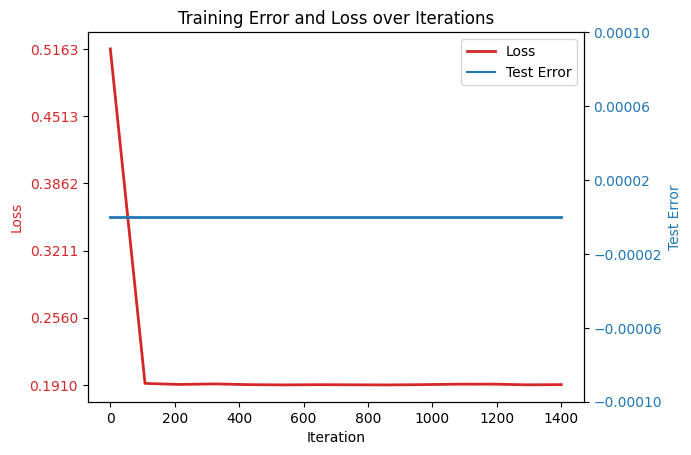

(np.float64(0.004608294930875576), np.float64(0.0))

In [8]:
WriteOutputEvery = 100


SVM_instance = SVM(X_train_input=X_train, y_train_input=y_train, X_test_input=X_test, y_test_input=y_test, FilterDeadPixels=True, WriteOutputEvery=WriteOutputEvery)

beta_array,b_array = SVM_instance.fit_SVM(learning_rate=0.3, lambda_reg=0.51, max_iterations= 10e5, threshold=1e-5)
#SVM_instance.visualise_clusters(resolution=200, title_text = "for all pixels via SVM")
SVM_instance.evaluate(plot=True)



In [10]:
Lambda_values = np.linspace(0.3, 0.8, 15)
training_errs, test_errs = SVM_CrossValidation(X_train, y_train, n_splits=5, test_size=0.4, random_state=5, lambda_reg = Lambda_values, threshold=1e-5)

Convergence reached.
Training error: = 0.77 %
Test error: = 3.45 %
Convergence reached.
Training error: = 0.0 %
Test error: = 4.6 %
Convergence reached.
Training error: = 0.77 %
Test error: = 4.6 %
Convergence reached.
Training error: = 0.0 %
Test error: = 4.6 %
Convergence reached.
Training error: = 0.77 %
Test error: = 1.15 %
Lambda value: 0.3
Average training error across splits:  0.45999999999999996 %
Average test error across splits:  3.6799999999999997 %
Training error: = 0.77 %
Test error: = 3.45 %
Convergence reached.
Training error: = 0.0 %
Test error: = 4.6 %
Convergence reached.
Training error: = 0.77 %
Test error: = 3.45 %
Convergence reached.
Training error: = 0.0 %
Test error: = 4.6 %
Convergence reached.
Training error: = 0.0 %
Test error: = 1.15 %
Lambda value: 0.3357142857142857
Average training error across splits:  0.31 %
Average test error across splits:  3.45 %
Convergence reached.
Training error: = 0.77 %
Test error: = 2.3 %
Convergence reached.
Training error: = 

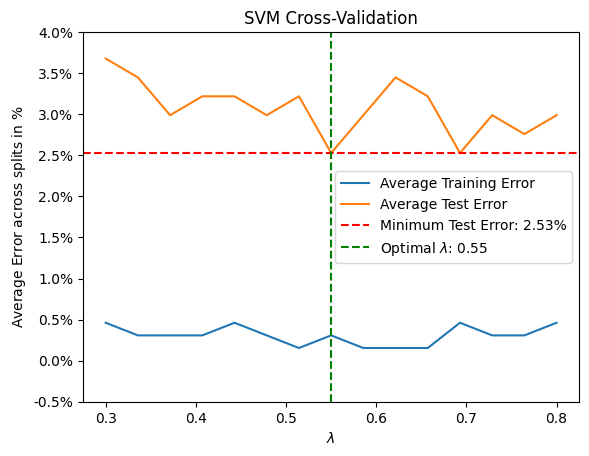

In [11]:
Lambda_min = np.argmin(test_errs)
test_error_min = test_errs[Lambda_min]
plt.plot(Lambda_values, training_errs, label=rf"Average Training Error")
plt.plot(Lambda_values, test_errs, label=rf"Average Test Error")
plt.xlabel(rf"$ \lambda$")
plt.ylabel(rf"Average Error across splits in $\%$")
plt.title(rf"SVM Cross-Validation")
plt.axhline(y = test_error_min, color='red', linestyle='--', label=f"Minimum Test Error: {test_error_min*100:.2f}%")
plt.axvline(x = Lambda_values[Lambda_min], color='green', linestyle='--', label=rf"Optimal $ \lambda$: {Lambda_values[Lambda_min]:.2f}")
yticks = plt.yticks()[0]
plt.yticks(yticks, [f"{v*100:.1f}%" for v in yticks])
plt.legend()
plt.show()

In [12]:

def run_custom_svm_cv(X, y, DataSplit, method_name="", PlotDataSplits=False):
    """Evaluate the custom SVM across precomputed validation splits."""
    training_errors = []
    test_errors = []
    for train_index, test_index in DataSplit:
                
        Lambda_optimal = 0.51
        WriteOutputEvery = 500

        SVM_instance = SVM(X_train_input=X[train_index], y_train_input=y[train_index], X_test_input=X[test_index], y_test_input=y[test_index], FilterDeadPixels=True, WriteOutputEvery=WriteOutputEvery)

        beta_array,b_array = SVM_instance.fit_SVM(learning_rate=0.3, lambda_reg=Lambda_optimal, max_iterations= 10e5, threshold=1e-4, PrintProgress=False)
        training_err, test_err=  SVM_instance.evaluate(plot=False)
        training_errors.append(training_err)
        test_errors.append(test_err)
        del(SVM_instance)
    
    average_training_error = np.mean(training_errors)
    average_test_error = np.mean(test_errors)
    print("Average training error across splits: ", np.round(average_training_error, 4)*100, "%")
    print("Average test error across splits: ", np.round(average_test_error, 4)*100, "%")

    if PlotDataSplits:
        fig, axes = plt.subplots(
            len(DataSplit),
            1,
            figsize=(12, 5),
            sharex=True,
            constrained_layout=True
        )

        # Normalise the single-split case to an iterable of axes.
        if len(DataSplit) == 1:
            axes = [axes]

        
        fig.suptitle("K-Fold Cross Validation Splits "+ method_name, fontsize=16)
        
        fig.supxlabel("Sample Index")
        fig.supylabel("Split Index")

        n_samples = len(y_all)

        for split_idx, (train_idx, test_idx) in enumerate(DataSplit):

            ax = axes[split_idx]

            # Background: all samples
            ax.barh(
                y=0,
                width=n_samples,
                left=0,
                height=0.6,
                color="lightgray",
                edgecolor="none"
            )

            # Training samples
            ax.barh(
                y=np.zeros_like(train_idx),
                width=1,
                left=train_idx,
                height=0.6,
                color="skyblue",
                edgecolor="none"
            )

            # Test samples
            ax.barh(
                y=np.zeros_like(test_idx),
                width=1,
                left=test_idx,
                height=0.6,
                color="salmon",
                edgecolor="none"
            )

            ax.set_yticks([])
            ax.set_ylabel(f"{split_idx+1}", rotation=0, labelpad=15)

            # Global x ticks
            axes[-1].set_xticks(np.arange(0, n_samples + 1, 20))

            # Remove unnecessary spines
            for ax in axes:
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['left'].set_visible(False)

            # Proper legend
            legend_elements = [
                Patch(facecolor='skyblue', label='Training Set'),
                Patch(facecolor='salmon', label='Test Set'),
            ]

        fig.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True
        )

        plt.show()

    return [average_training_error, average_test_error]

Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 2.74 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.0 %
Test error: = 2.0500000000000003 %
Convergence reached.
Training error: = 0.0 %
Test error: = 1.37 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 0.6799999999999999 %
Convergence reached.
Training error: = 1.8399999999999999 %
Test error: = 2.74 %
Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 1.37 %
Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 2.74 %
Convergence reached.
Training error: = 1.38 %
Test error: = 4.109999999999999 %
Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 0.6799999999999999 %
Average training error across splits:  0.74 %
Average test error across splits:  1.8499999999999999 %


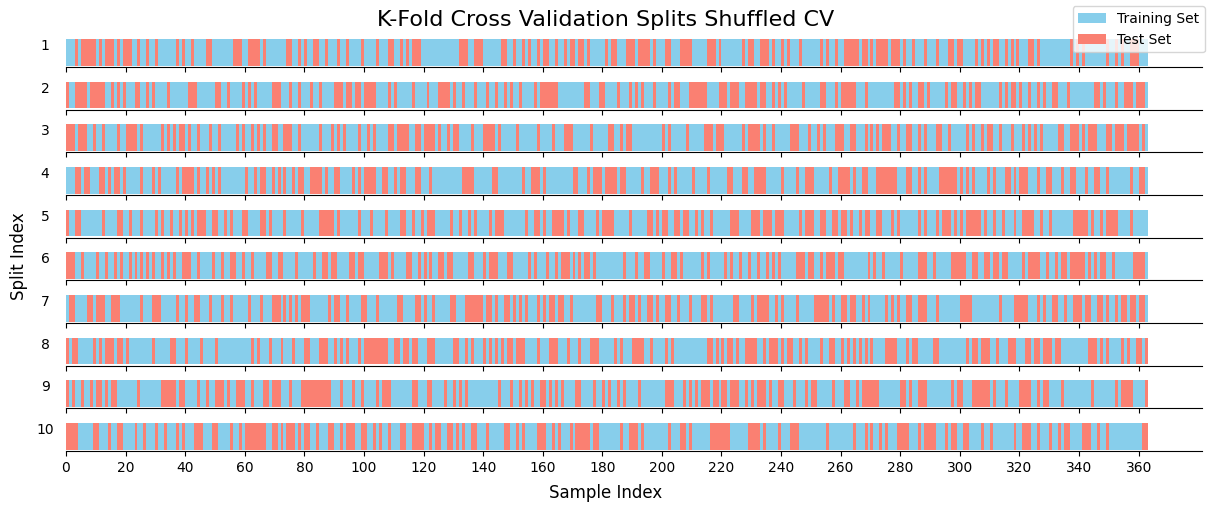

In [196]:
SVM_ShuffleSplitErrors =run_custom_svm_cv(X_all, y_all, DataSplit_Shuffled, method_name = "Shuffled CV", PlotDataSplits=True)

Convergence reached.
Training error: = 1.23 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.61 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.61 %
Test error: = 2.7 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.61 %
Test error: = 2.78 %
Convergence reached.
Training error: = 0.61 %
Test error: = 2.78 %
Convergence reached.
Training error: = 0.61 %
Test error: = 0.0 %
Convergence reached.
Training error: = 1.53 %
Test error: = 2.78 %
Average training error across splits:  0.86 %
Average test error across splits:  1.0999999999999999 %


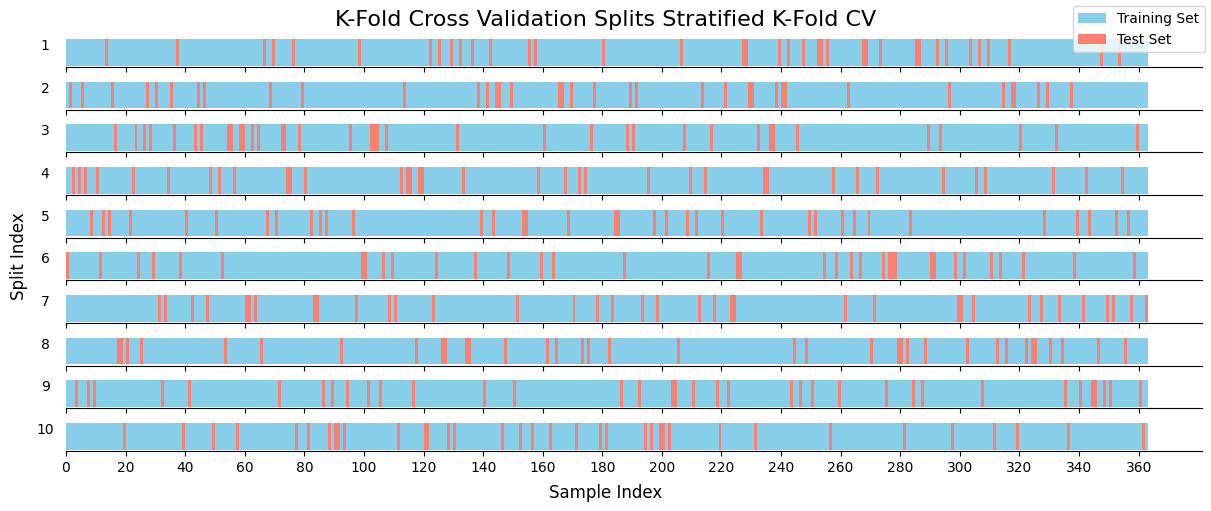

In [197]:
SVM_StratifiedKFoldErrors =run_custom_svm_cv(X_all, y_all, DataSplit_StratifiedKFold, method_name = "Stratified K-Fold CV", PlotDataSplits=True)

Convergence reached.
Training error: = 1.38 %
Test error: = 0.6799999999999999 %
Convergence reached.
Training error: = 0.0 %
Test error: = 2.0500000000000003 %
Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 0.0 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 2.0500000000000003 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 2.74 %
Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 0.6799999999999999 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 4.109999999999999 %
Convergence reached.
Training error: = 0.9199999999999999 %
Test error: = 0.6799999999999999 %
Convergence reached.
Training error: = 0.0 %
Test error: = 2.0500000000000003 %
Convergence reached.
Training error: = 0.45999999999999996 %
Test error: = 2.0500000000000003 %
Average training error across splits:  0.65 %
Average test error across splits:  1.71 %


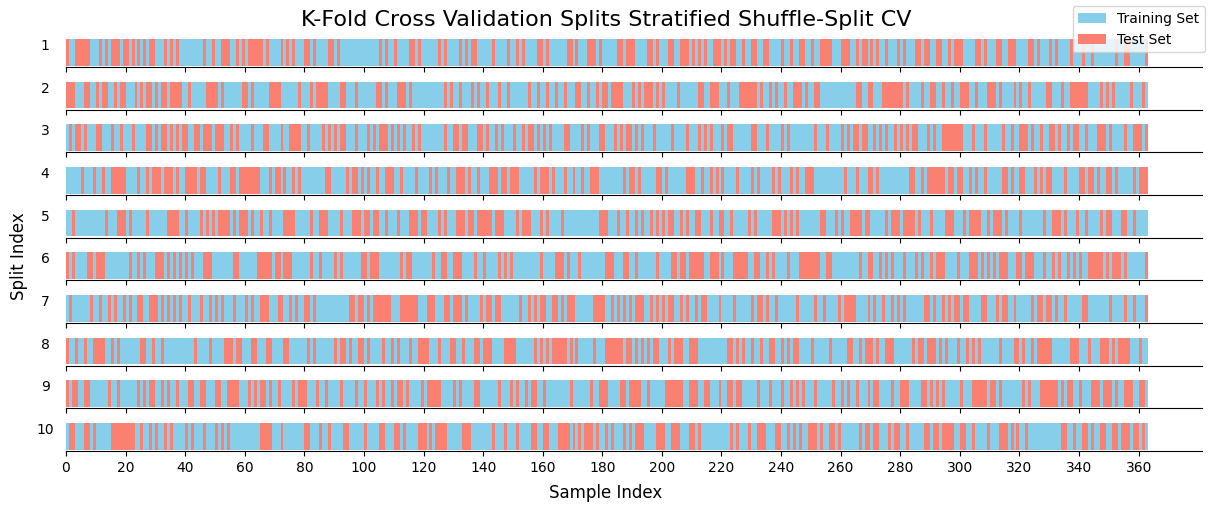

In [198]:
SVM_StratifiedShuffleSplitErrors =run_custom_svm_cv(X_all, y_all, DataSplit_StratifiedShuffleSplit, method_name = "Stratified Shuffle-Split CV", PlotDataSplits=True)

## Reference implementation: scikit-learn linear SVM

The reference model provides a library baseline under the same validation splits. It helps distinguish implementation-specific behaviour from the limits of the linear model itself.

In [ ]:

def run_sklearn_svm_cv(X, y, DataSplit, method_name="", PlotDataSplits=False):
    """Evaluate scikit-learn linear SVM across precomputed validation splits."""
    training_errors = []
    test_errors = []
    for train_index, test_index in DataSplit:
        
        svm_classifier = svm.SVC(kernel='linear', C=2.0)
        svm_classifier.fit(X[train_index], y[train_index])
        train_predictions = svm_classifier.predict(X[train_index])
        test_predictions = svm_classifier.predict(X[test_index])
        training_err = np.mean(train_predictions != y[train_index])
        test_err = np.mean(test_predictions != y[test_index])
        training_errors.append(training_err)
        test_errors.append(test_err)
        del(svm_classifier)
        
        

    average_training_error = np.mean(training_errors)
    average_test_error = np.mean(test_errors)
    print("Average training error across splits: ", np.round(average_training_error, 4)*100, "%")
    print("Average test error across splits: ", np.round(average_test_error, 4)*100, "%")
    


    if PlotDataSplits:
        fig, axes = plt.subplots(
            len(DataSplit),
            1,
            figsize=(12, 5),
            sharex=True,
            constrained_layout=True
        )

        # Normalise the single-split case to an iterable of axes.
        if len(DataSplit) == 1:
            axes = [axes]

        
        fig.suptitle("K-Fold Cross Validation Splits "+ method_name, fontsize=16)
        
        fig.supxlabel("Sample Index")
        fig.supylabel("Split Index")

        n_samples = len(y_all)

        for split_idx, (train_idx, test_idx) in enumerate(DataSplit):

            ax = axes[split_idx]

            # Background: all samples
            ax.barh(
                y=0,
                width=n_samples,
                left=0,
                height=0.6,
                color="lightgray",
                edgecolor="none"
            )

            # Training samples
            ax.barh(
                y=np.zeros_like(train_idx),
                width=1,
                left=train_idx,
                height=0.6,
                color="skyblue",
                edgecolor="none"
            )

            # Test samples
            ax.barh(
                y=np.zeros_like(test_idx),
                width=1,
                left=test_idx,
                height=0.6,
                color="salmon",
                edgecolor="none"
            )

            ax.set_yticks([])
            ax.set_ylabel(f"{split_idx+1}", rotation=0, labelpad=15)

            # Global x ticks
            axes[-1].set_xticks(np.arange(0, n_samples + 1, 20))

            # Remove unnecessary spines
            for ax in axes:
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['left'].set_visible(False)

            # Proper legend
            legend_elements = [
                Patch(facecolor='skyblue', label='Training Set'),
                Patch(facecolor='salmon', label='Test Set'),
            ]

        fig.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True
        )

        plt.show()

    return [average_training_error, average_test_error]

Average training error across splits:  0.0 %
Average test error across splits:  1.78 %


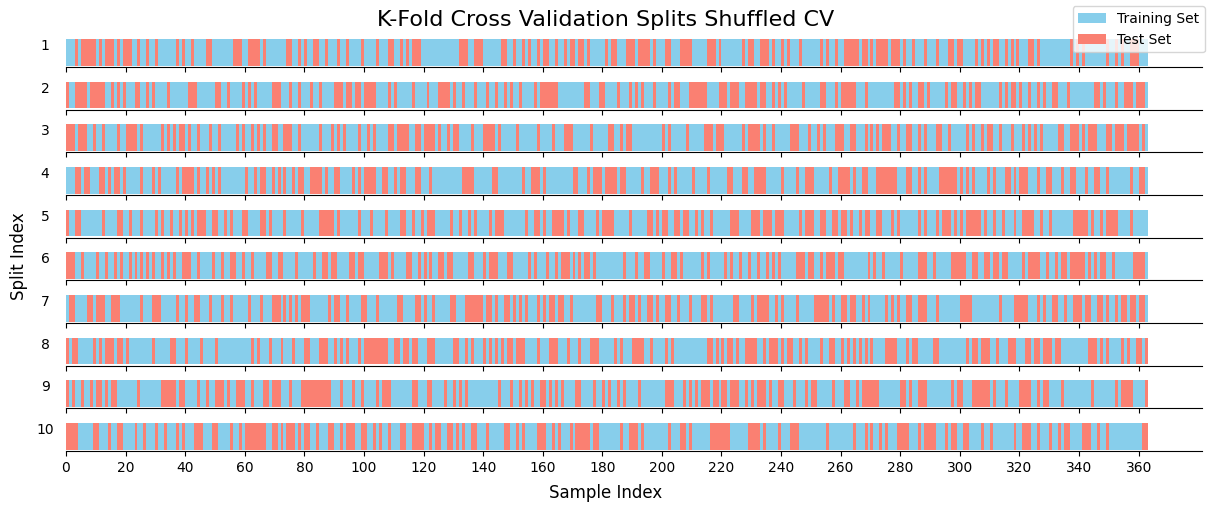

In [200]:
Sklearn_ShuffleSplitErrors =run_sklearn_svm_cv(X_all, y_all, DataSplit_Shuffled, method_name = "Shuffled CV", PlotDataSplits=True)

Average training error across splits:  0.0 %
Average test error across splits:  2.21 %


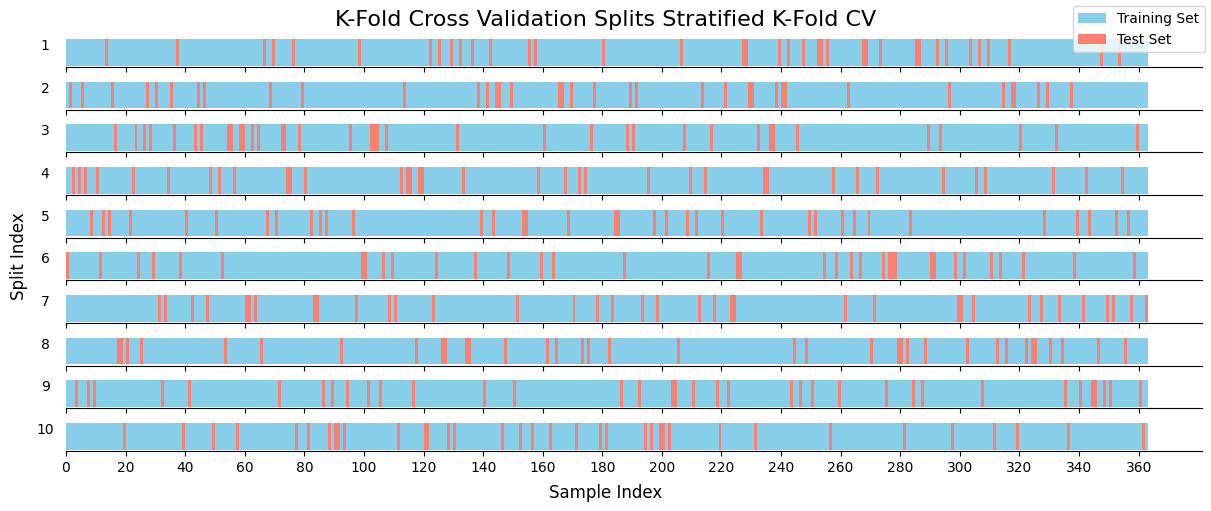

In [201]:
Sklearn_StratifiedKFoldErrors =run_sklearn_svm_cv(X_all, y_all, DataSplit_StratifiedKFold, method_name = "Stratified K-Fold CV", PlotDataSplits=True)

Average training error across splits:  0.0 %
Average test error across splits:  1.78 %


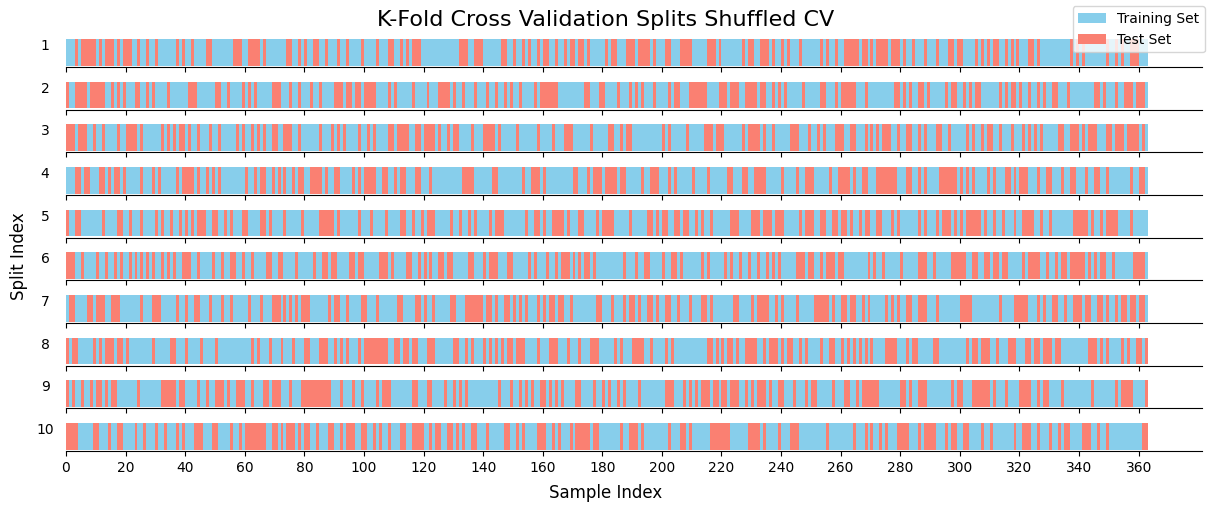

In [202]:
Sklearn_SVM_ShuffleSplitErrors =run_sklearn_svm_cv(X_all, y_all, DataSplit_Shuffled, method_name = "Shuffled CV", PlotDataSplits=True)

In [203]:
SVM_results = [SVM_ShuffleSplitErrors[1], SVM_StratifiedKFoldErrors[1], SVM_StratifiedShuffleSplitErrors[1]]
LDA_results = [LDA_ShuffledErrors[1], LDA_StratifiedKFoldErrors[1], LDA_StratifiedShuffleSplitErrors[1]]
Sklearn_SVM_results = [Sklearn_ShuffleSplitErrors[1], Sklearn_StratifiedKFoldErrors[1], Sklearn_SVM_ShuffleSplitErrors[1]]

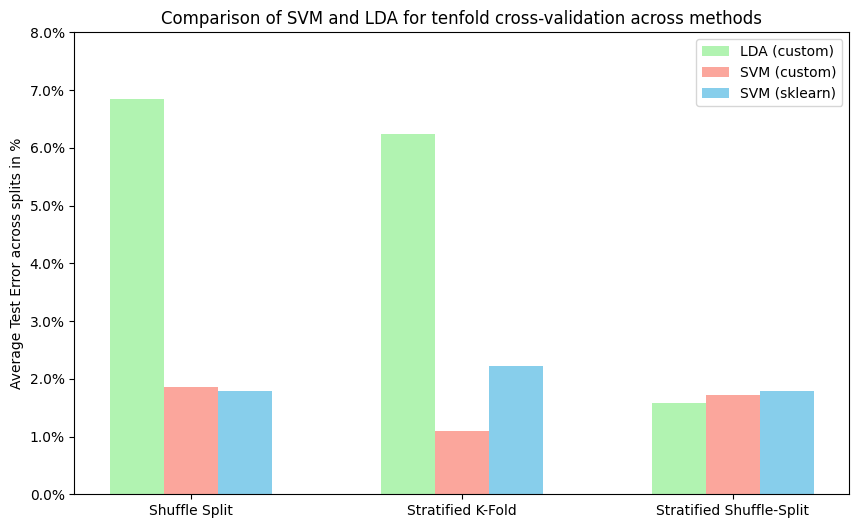

In [204]:
labels = ["Shuffle Split", "Stratified K-Fold", "Stratified Shuffle-Split"]

group_spacing = 1.5  # increase this for more space between groups
x = np.arange(len(labels)) * group_spacing
width = 0.3

fig = plt.figure(figsize=(10, 6))
plt.bar(x - width, LDA_results, width=width, color='lightgreen', label='LDA (custom)', alpha=0.7)
plt.bar(x, SVM_results, width=width, color='salmon', label='SVM (custom)', alpha=0.7)
plt.bar(x + width, Sklearn_SVM_results, width=width, color='skyblue', label='SVM (sklearn)')

plt.xticks(x, labels)
plt.ylabel("Average Test Error across splits in %")
plt.title("Comparison of SVM and LDA for tenfold cross-validation across methods")
yticks = plt.yticks()[0]
plt.yticks(yticks, [f"{v*100:.1f}%" for v in yticks])
plt.legend()
plt.show()

## Conclusion

The notebook shows that a linear SVM can classify the selected 3-versus-9 subset with low held-out error. Across the saved evaluation runs, the custom implementation was broadly comparable to the scikit-learn linear SVM baseline, while LDA varied more strongly with the validation split.

PCA provides an interpretable low-dimensional view of the decision boundary, but it is not used as a substitute for higher-dimensional evaluation. The main lesson is methodological: implementation choices and validation design both materially affect reported model performance.

### Reproducibility note

The fixed introductory split uses a defined random seed. The SVM weight initialisation is random, so exact re-runs can vary slightly. For a production-quality benchmark, use an explicit initialisation seed, nested cross-validation for hyperparameter selection, and uncertainty estimates across folds.

In exercise 3, we implemented a Linear Discriminant Analysis (LDA) classifier from scratch and evalueated its performance with various cross-validation schemes. 

In the third exercise we implemented a Support Vector Machine (SVM) using gradient descent to minimise the loss function. 
The hyperparameter $ \lambda $ was obtained via Grid Search, evaluated on the same cross-validation splits as for LDA, and the results were compared to those obtained with LDA. We also compared our custom SVM implementation to the SVM implementation from sklearn. The results showed, that our SVM implementation outperformed LDA in al three cross-validation methods. Even though Sklearn performed better in one of the cross-validation methods, our custom SVM implementation performed better or comparable in the other two methods. 